In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score


from pathlib import Path
import sys

MAL_DIR = Path.cwd()
if MAL_DIR.name != "MAL":
    MAL_DIR = next(path for path in [Path.cwd(), *Path.cwd().parents] if path.name == "MAL")

sys.path.insert(0, str(MAL_DIR))
from scripts.preprocessing import AutomatedPreprocessor

# Here we import and split the data
df = pd.read_csv("../../data/processed/linearized_session_windows_30min.csv")

TARGET_COLUMN = "focus_score"
columns_to_ignore = [TARGET_COLUMN]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Usage from scripts/
preprocessor = AutomatedPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


In [9]:
# Random Forest Classification

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[[
    "mean_test_score",
    "std_test_score",
    "mean_fit_time",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_class_weight",
]].sort_values(by="mean_test_score", ascending=False)

results_df

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}
Best CV f1_macro: 0.2106


,mean_test_score,std_test_score,mean_fit_time,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_class_weight
44,0.210592,0.001290,26.386528,400,10,10,2,balanced
37,0.210007,0.000574,13.467849,200,10,2,2,balanced
31,0.209933,0.002356,14.589514,200,10,5,1,balanced
41,0.209495,0.001970,28.653480,400,10,5,2,balanced
47,0.209274,0.002031,26.402755,400,10,2,4,balanced
...,...,...,...,...,...,...,...,...
65,0.172320,0.002124,66.418372,400,20,2,2,balanced
59,0.170194,0.001303,57.282339,400,20,5,1,balanced
54,0.165327,0.000631,21.258421,100,20,2,1,balanced
55,0.159623,0.001370,61.037842,200,20,2,1,balanced



--- Train Metrics ---
Accuracy:  0.4817
Precision (weighted): 0.5517
Recall (weighted):    0.4817
F1 Score (weighted):  0.5071

--- Test/Validation Metrics ---
Accuracy:  0.3089
Precision (weighted): 0.3450
Recall (weighted):    0.3089
F1 Score (weighted):  0.3223

--- Feature Importances (Top 20) ---
temperature_mean_temperature_max_temperature_latest_temperature_min    0.221176
co2_mean_co2_max_co2_latest_co2_min                                    0.087610
light_mean_light_max                                                   0.085744
co2_std_co2_range                                                      0.081646
light_std_light_range                                                  0.077857
light_latest                                                           0.075888
noise_min_noise_latest_noise_mean_noise_max                            0.075560
noise_std_noise_range                                                  0.067468
humidity_mean_humidity_min_humidity_latest_humidity_max 

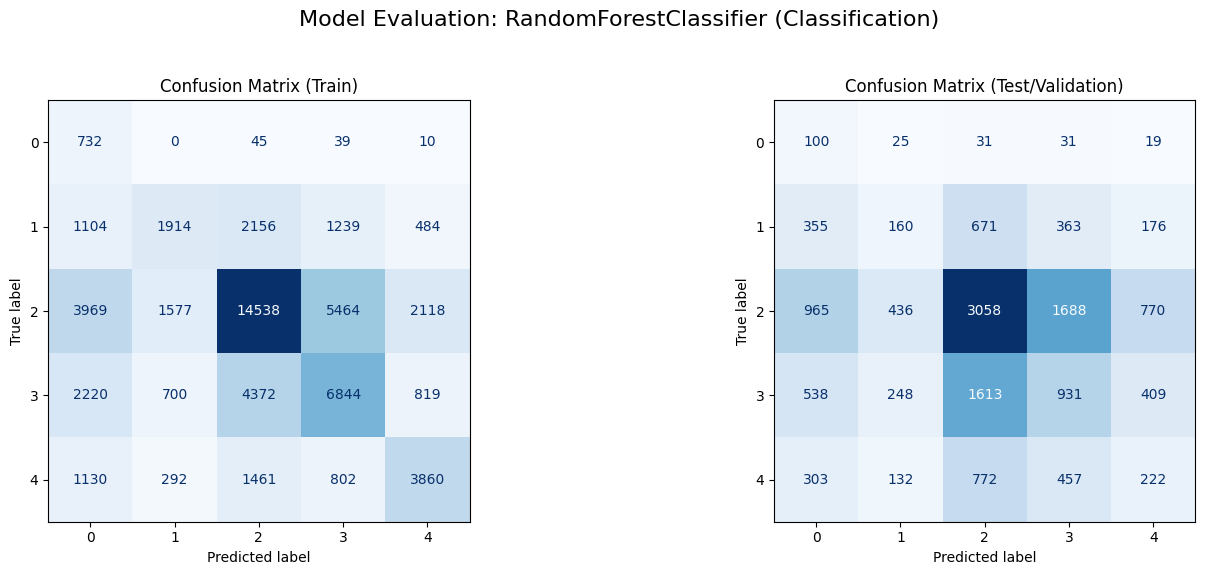

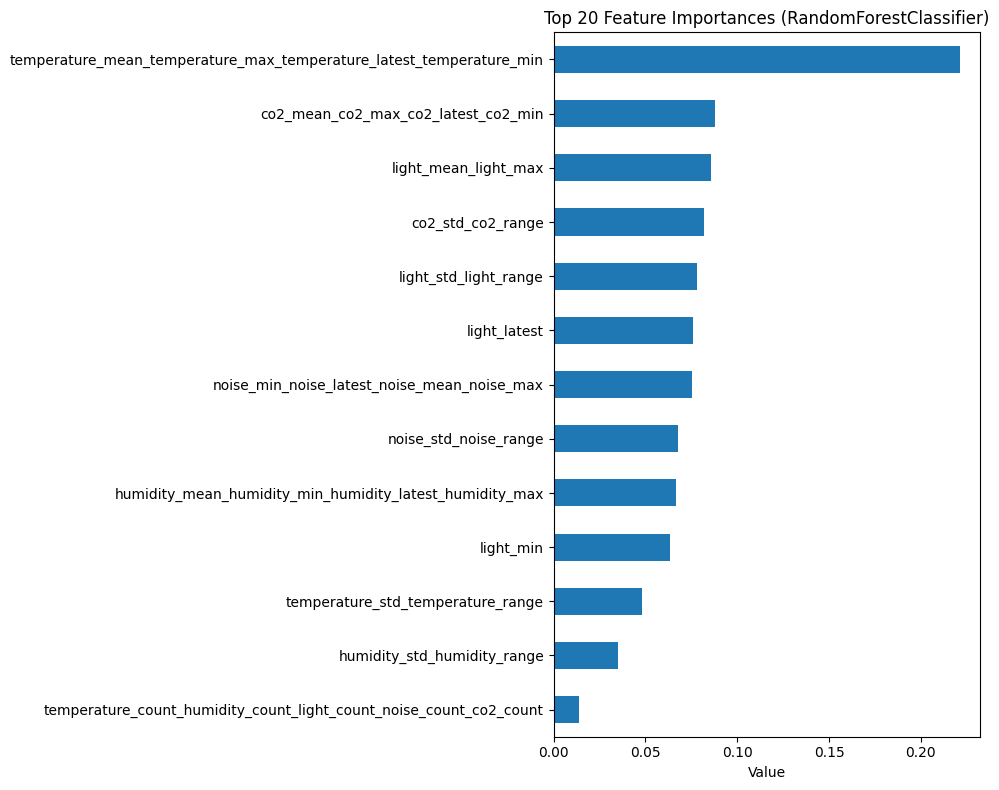

In [10]:
import importlib
import scripts.evaluation_metrics
importlib.reload(scripts.evaluation_metrics)
from scripts.evaluation_metrics import evaluate_model

best_model.fit(X_train_processed, y_train)

evaluate_model(best_model, X_train_processed, X_val_processed, y_train, y_val, True);

## Conclusion

The Random Forest Classifier currently appears to be the best choice for our prediction task.

It handles the imbalanced nature of our dataset better than the simple linear models in Notebook 5 and matches (or even exceeds) the performance of the neural networks in Notebook 4. The weighted approach (class_weight='balanced') is particularly effective at catching rare ratings without sacrificing too much overall accuracy.

Unlike the Neural Networks, the Random Forest is much less prone to overfitting on our small dataset. It also provides a clear 'Feature Importance' ranking which is very useful for our project development.

Going forward, this model strikes the best balance between performance, explainability, and ease of deployment. While Neural Networks (Notebook 4) might eventually win with more data, the Random Forest is our current champion for production use.
